# Задание 2

### Графический анализ

Ключевые зависимости

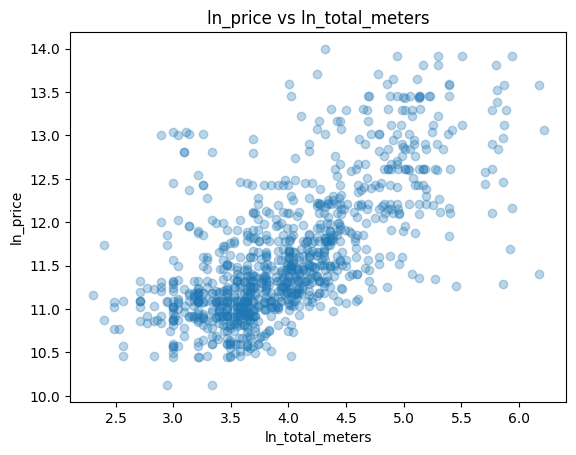

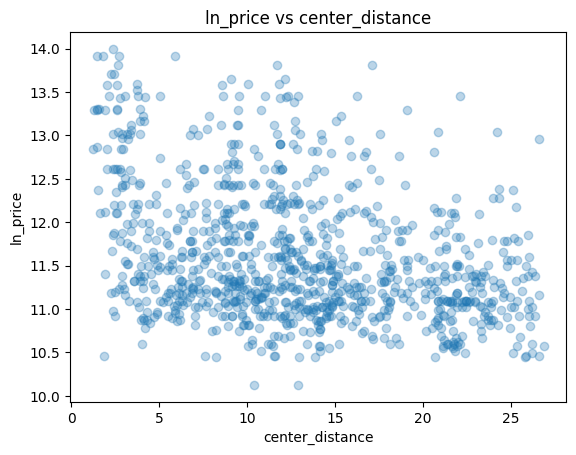

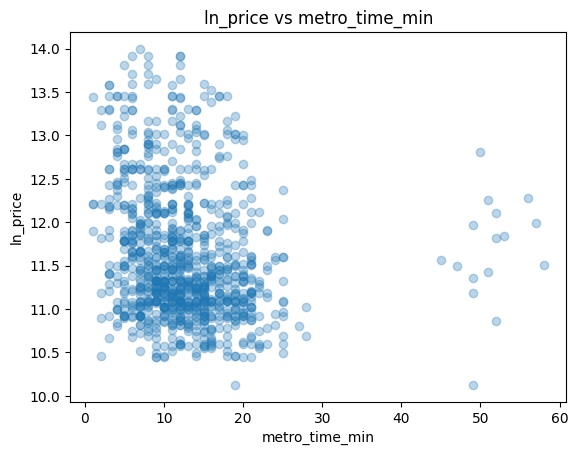

In [ ]:
pairs = ['ln_total_meters', 'center_distance', 'metro_time_min']

for col in pairs:
    plt.figure()
    plt.scatter(df[col], df['ln_price'], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel('ln_price')
    plt.title(f'ln_price vs {col}')
    plt.show()

3) комнаты и ремонт

<Figure size 640x480 with 0 Axes>

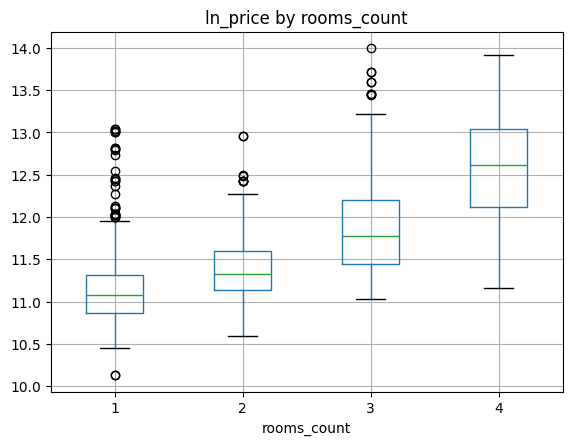

<Figure size 800x500 with 0 Axes>

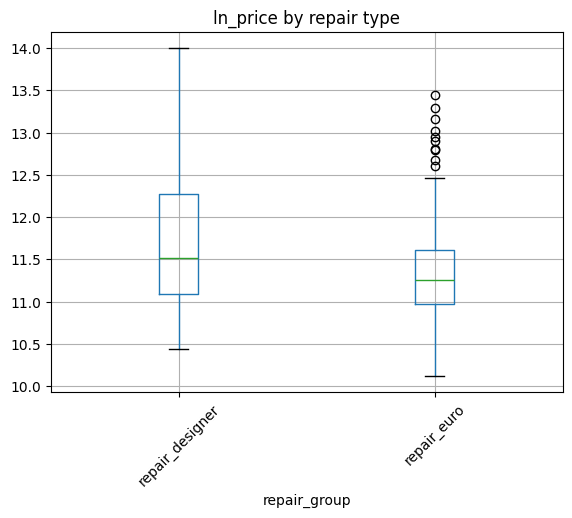

In [ ]:
plt.figure()
df.boxplot(column='ln_price', by='rooms_count')
plt.title('ln_price by rooms_count')
plt.suptitle('')
plt.show()

repair_cols = [c for c in df.columns if 'repair_' in c]
df['repair_group'] = df[repair_cols].idxmax(axis=1)
plt.figure(figsize=(8,5))
df.boxplot(column='ln_price', by='repair_group')
plt.xticks(rotation=45)
plt.title('ln_price by repair type')
plt.suptitle('')
plt.show()

4) условия аренды

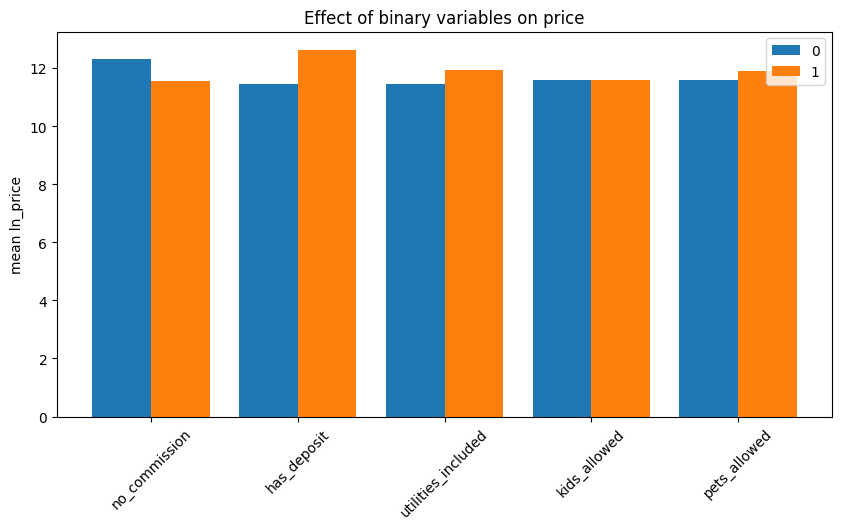

In [ ]:

binary_cols = [
    'no_commission', 'has_deposit', 'utilities_included',
    'kids_allowed', 'pets_allowed'
]

results = []

for col in binary_cols:
    means = df.groupby(col)['ln_price'].mean()
    results.append({
        'variable': col,
        'value_0': means.get(0, None),
        'value_1': means.get(1, None)
    })

plot_df = pd.DataFrame(results)

x = range(len(plot_df))

plt.figure(figsize=(10,5))
plt.bar(x, plot_df['value_0'], width=0.4, label='0', align='center')
plt.bar([i + 0.4 for i in x], plot_df['value_1'], width=0.4, label='1', align='center')

plt.xticks([i + 0.2 for i in x], plot_df['variable'], rotation=45)
plt.ylabel('mean ln_price')
plt.title('Эффект бин. условий аренды на лог. цены')
plt.legend()
plt.show()

корреляции

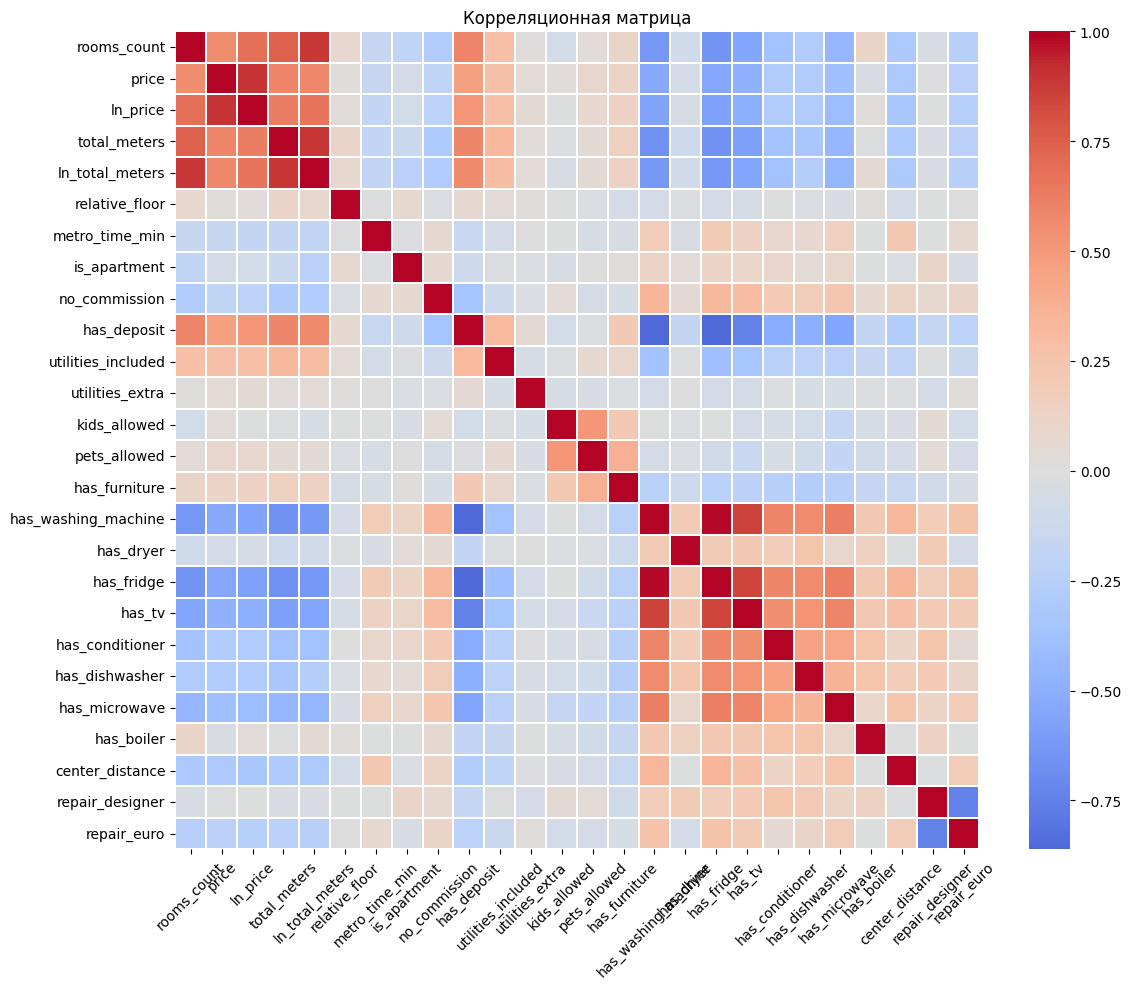

In [ ]:
import seaborn as sns

num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.3,
    cbar=True
)

plt.title('Корреляционная матрица')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Описательная статистика

создаем эксель таблички с описательной статистикой переменных, которые приложим в отчете в формате:


In [ ]:
import pandas as pd
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

amenities = [
    "has_furniture", "has_washing_machine", "has_dryer", "has_fridge",
    "has_tv", "has_conditioner", "has_dishwasher", "has_microwave", "has_boiler"
]

df["amenities_count"] = df[amenities].sum(axis=1)

meta = {
    "price": ["количественная", "руб./мес.", "цена аренды из объявления"],
    "ln_price": ["количественная", "лог руб./мес.", "натуральный логарифм price"],
    "total_meters": ["количественная", "м²", "общая площадь из объявления"],
    "ln_total_meters": ["количественная", "лог м²", "натуральный логарифм total_meters"],
    "rooms_count": ["дискретная", "число комнат", "количество комнат из объявления"],
    "relative_floor": ["количественная", "доля от 0 до 1", "этаж квартиры / этажность дома"],

    "metro_time_min": ["количественная", "минуты", "время пешком до ближайшего метро"],
    "center_distance": ["количественная", "км", "расстояние до метро + расстояние от метро до центра"],
    "is_apartment": ["бинарная", "1 — апартаменты, 0 — квартира", "dummy по типу объекта"],
    "no_commission": ["бинарная", "1 — нет комиссии, 0 — есть", "dummy по условиям аренды"],
    "has_deposit": ["бинарная", "1 — есть залог, 0 — нет", "dummy по условиям аренды"],
    "utilities_included": ["бинарная", "1 — ЖКУ включены, 0 — нет", "dummy по условиям аренды"],
    "utilities_extra": ["бинарная", "1 — ЖКУ оплачиваются отдельно, 0 — иначе", "dummy по условиям аренды"],
    "kids_allowed": ["бинарная", "1 — можно с детьми, 0 — нельзя", "dummy из условий объявления"],
    "pets_allowed": ["бинарная", "1 — можно с животными, 0 — нельзя", "dummy из условий объявления"],

    "has_furniture": ["бинарная", "1 — есть, 0 — нет", "наличие мебели"],
    "has_washing_machine": ["бинарная", "1 — есть, 0 — нет", "наличие стиральной машины"],
    "has_dryer": ["бинарная", "1 — есть, 0 — нет", "наличие сушильной машины"],
    "has_fridge": ["бинарная", "1 — есть, 0 — нет", "наличие холодильника"],
    "has_tv": ["бинарная", "1 — есть, 0 — нет", "наличие телевизора"],
    "has_conditioner": ["бинарная", "1 — есть, 0 — нет", "наличие кондиционера"],
    "has_dishwasher": ["бинарная", "1 — есть, 0 — нет", "наличие посудомоечной машины"],
    "has_microwave": ["бинарная", "1 — есть, 0 — нет", "наличие микроволновой печи"],
    "has_boiler": ["бинарная", "1 — есть, 0 — нет", "наличие водонагревателя"],
    "repair_designer": ["бинарная", "1 — дизайнерский ремонт, 0 — иначе", "dummy из repair_type"],
    "repair_euro": ["бинарная", "1 — евроремонт, 0 — иначе", "dummy из repair_type"],
    "amenities_count": ["дискретная", "количество удобств", "сумма бинарных переменных оснащения"]
}

groups = {
    "1_Цена_и_характеристики": [
        "price", "ln_price", "total_meters", "ln_total_meters",
        "rooms_count", "relative_floor"
    ],
    "2_Локация_и_условия": [
        "metro_time_min", "center_distance", "is_apartment",
        "no_commission", "has_deposit", "utilities_included",
        "utilities_extra", "kids_allowed", "pets_allowed"
    ],
    "3_Оснащение_и_ремонт": [
        "has_furniture", "has_washing_machine", "has_dryer", "has_fridge",
        "has_tv", "has_conditioner", "has_dishwasher", "has_microwave",
        "has_boiler", "repair_designer", "repair_euro", "amenities_count"
    ]
}

def make_table(cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        rows.append({
            "Переменная": col,
            "Тип": meta[col][0],
            "Единица измерения / кодировка": meta[col][1],
            "Как рассчитывается": meta[col][2],
            "Mean": s.mean(),
            "Std": s.std(),
            "Min": s.min(),
            "25%": s.quantile(0.25),
            "50%": s.quantile(0.50),
            "75%": s.quantile(0.75),
            "Max": s.max()
        })
    return pd.DataFrame(rows)

with pd.ExcelWriter("tables_for_report.xlsx", engine="openpyxl") as writer:
    for sheet_name, cols in groups.items():
        table = make_table(cols)
        table.to_excel(writer, sheet_name=sheet_name, index=False)

        ws = writer.book[sheet_name]

        border = Border(
            left=Side(style="thin"),
            right=Side(style="thin"),
            top=Side(style="thin"),
            bottom=Side(style="thin")
        )

        for row in ws.iter_rows():
            for cell in row:
                cell.border = border
                cell.alignment = Alignment(wrap_text=True, vertical="top")

        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(wrap_text=True, horizontal="center", vertical="top")

        widths = [20, 18, 30, 42, 11, 11, 11, 11, 11, 11, 11]
        for i, width in enumerate(widths, start=1):
            ws.column_dimensions[get_column_letter(i)].width = width

        for row in ws.iter_rows(min_row=2, min_col=5, max_col=11):
            for cell in row:
                cell.number_format = "0.00"

        ws.freeze_panes = "A2"

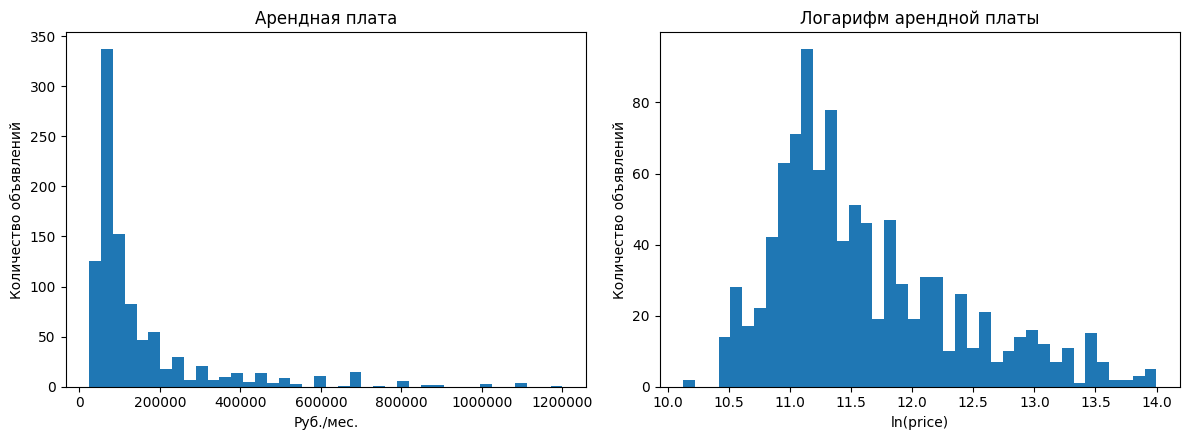

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("data.xlsx")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["price"].dropna(), bins=40)
axes[0].set_title("Арендная плата")
axes[0].set_xlabel("Руб./мес.")
axes[0].set_ylabel("Количество объявлений")
axes[0].ticklabel_format(style="plain", axis="x")

axes[1].hist(df["ln_price"].dropna(), bins=40)
axes[1].set_title("Логарифм арендной платы")
axes[1].set_xlabel("ln(price)")
axes[1].set_ylabel("Количество объявлений")

plt.tight_layout()
plt.show()

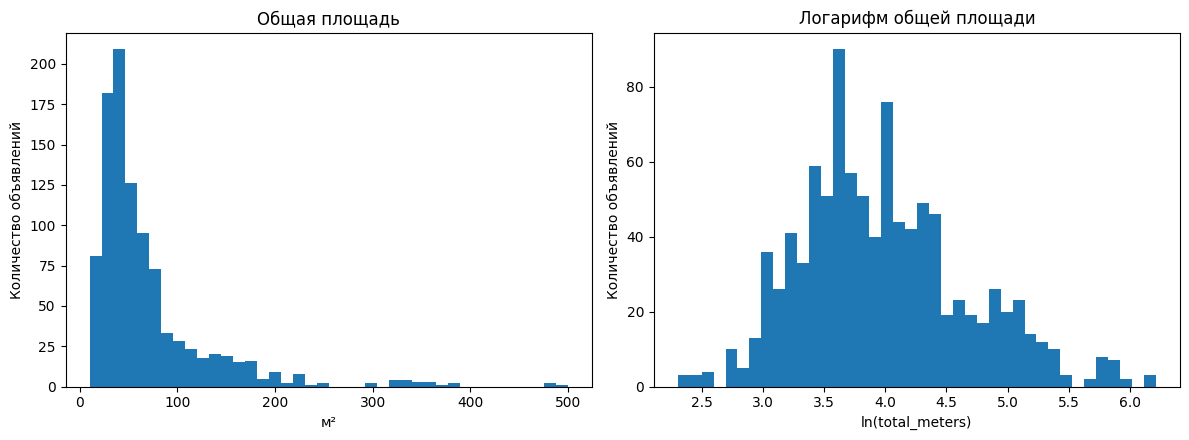

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["total_meters"].dropna(), bins=40)
axes[0].set_title("Общая площадь")
axes[0].set_xlabel("м²")
axes[0].set_ylabel("Количество объявлений")

axes[1].hist(df["ln_total_meters"].dropna(), bins=40)
axes[1].set_title("Логарифм общей площади")
axes[1].set_xlabel("ln(total_meters)")
axes[1].set_ylabel("Количество объявлений")

plt.tight_layout()
plt.show()